# Trabalho Prático 03 - MLPClassifier (Scikit-learn)

**Disciplina:** GCC 128 - Inteligência Artificial  
**Professor:** Ahmed Ali Abdalla Esmin  
**Alunos:** Daniel de Jesus Moreira, João Guilherme Santos Ribeiro

---

## Introdução

Este notebook aplica o classificador **MLPClassifier** (Perceptron Multicamadas) para tarefas de classificação supervisionada, conforme o enunciado da atividade.

Serão utilizadas as bases **Iris** e **Wine**, com avaliação por métricas de desempenho e matriz de confusão. Ao final, os resultados podem ser comparados com o trabalho anterior de **KNN** (Trabalho Prático 01).

## 1. Importações Necessárias

Importamos bibliotecas para:

- manipulação de dados (`pandas`);
- visualização (`matplotlib`, `seaborn`);
- treinamento e avaliação com o `MLPClassifier`;
- escalonamento com `StandardScaler`.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Datasets direto do Sklearn
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split

# A Rede Neural (Multi-Layer Perceptron)
from sklearn.neural_network import MLPClassifier

# Métricas de avaliação 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score

from sklearn.preprocessing import StandardScaler

## 2. Carregamento e Divisão das Bases

Nesta etapa, carregamos as bases **Iris** e **Wine** diretamente do Scikit-learn e realizamos:

- divisão em **80% treino** e **20% teste**;
- separação das variáveis de entrada ($X$) e rótulos ($y$);
- definição das classes para uso nas matrizes de confusão.

A semente fixa é utilizada para garantir reprodutibilidade e consistência com os demais trabalhos.

In [10]:
# 1. Preparação da Base Iris
print("Carregando e preparando a base Iris...")
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
classes_iris = iris.target_names

# Dividindo 80% para treino e 20% para teste (semente 73 para consistência com o trab do KNN)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=73
)
print(f"Iris -> Treino: {X_train_i.shape[0]} amostras | Teste: {X_test_i.shape[0]} amostras.\n")

# 2. Preparação da Base Wine
print("Carregando e preparando a base Wine...")
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
classes_wine = wine.target_names

# Dividindo 80% para treino e 20% para teste (mesma semente 73)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=73
)
print(f"Wine -> Treino: {X_train_w.shape[0]} amostras | Teste: {X_test_w.shape[0]} amostras.")

Carregando e preparando a base Iris...
Iris -> Treino: 120 amostras | Teste: 30 amostras.

Carregando e preparando a base Wine...
Wine -> Treino: 142 amostras | Teste: 36 amostras.


## 3. Treinamento do MLPClassifier

Antes do treinamento, os dados são normalizados com **StandardScaler**, uma etapa essencial para redes neurais.

Em seguida, treinamos um MLP para cada base (Iris e Wine), medindo o **tempo de treinamento** e obtendo as previsões para o conjunto de teste.

In [11]:
# 1. Normalizando os dados da Iris
scaler_iris = StandardScaler()
X_train_i_scaled = scaler_iris.fit_transform(X_train_i)
X_test_i_scaled = scaler_iris.transform(X_test_i) 

# 2. Criando e treinando a Rede Neural da Iris
# hidden_layer_sizes=(100,) cria uma camada oculta com 100 neurônios
mlp_iris = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=73)
inicio_iris = time.time()
mlp_iris.fit(X_train_i_scaled, y_train_i)
tempo_iris = time.time() - inicio_iris

# 3. Fazendo as previsões
previsoes_iris = mlp_iris.predict(X_test_i_scaled)
print(f"Rede Neural IRIS treinada em {tempo_iris:.4f} segundos.")


# 1. Normalizando os dados do Wine
scaler_wine = StandardScaler()
X_train_w_scaled = scaler_wine.fit_transform(X_train_w)
X_test_w_scaled = scaler_wine.transform(X_test_w)

# 2. Criando e treinando a Rede Neural do Wine
mlp_wine = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=73)
inicio_wine = time.time()
mlp_wine.fit(X_train_w_scaled, y_train_w)
tempo_wine = time.time() - inicio_wine

# 3. Fazendo as previsões
previsoes_wine = mlp_wine.predict(X_test_w_scaled)
print(f"Rede Neural WINE treinada em {tempo_wine:.4f} segundos.")

Rede Neural IRIS treinada em 0.2151 segundos.
Rede Neural WINE treinada em 0.1421 segundos.


## 4. Avaliação dos Resultados

A avaliação é feita com:

- **classification report** (precisão, revocação, f1-score e acurácia);
- **matriz de confusão** para visualizar acertos e erros.

Os resultados são apresentados separadamente para as bases **Iris** e **Wine**, permitindo comparar a performance do MLP em diferentes conjuntos de dados.

   RESULTADOS: REDE NEURAL - BASE IRIS   
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.89      0.94         9
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



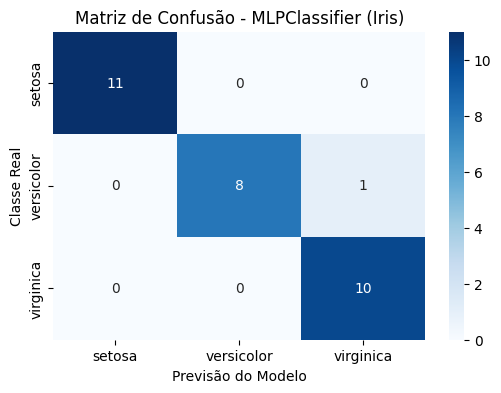


   RESULTADOS: REDE NEURAL - BASE WINE   
              precision    recall  f1-score   support

     class_0       1.00      0.91      0.95        11
     class_1       0.94      1.00      0.97        15
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



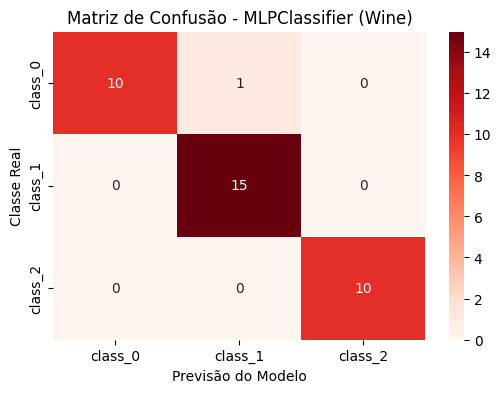

In [8]:
# 3. Avaliação da Base IRIS
print("=========================================")
print("   RESULTADOS: REDE NEURAL - BASE IRIS   ")
print("=========================================")

# classification_report traz acurácia, precisão, revocação e f1-score
print(classification_report(y_test_i, previsoes_iris, target_names=classes_iris))

# Plotando a Matriz de Confusão
matriz_iris = confusion_matrix(y_test_i, previsoes_iris)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_iris, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes_iris, yticklabels=classes_iris)
plt.title('Matriz de Confusão - MLPClassifier (Iris)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.show()


# 4. Avaliação da Base WINE
print("\n=========================================")
print("   RESULTADOS: REDE NEURAL - BASE WINE   ")
print("=========================================")
print(classification_report(y_test_w, previsoes_wine, target_names=classes_wine))

# Plotando a Matriz de Confusão
matriz_wine = confusion_matrix(y_test_w, previsoes_wine)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_wine, annot=True, fmt='d', cmap='Reds', 
            xticklabels=classes_wine, yticklabels=classes_wine)
plt.title('Matriz de Confusão - MLPClassifier (Wine)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.show()

## 5. Comparacao com o KNN (Trabalho 01)

Com base nos resultados obtidos, a comparação com o KNN pode ser resumida assim:

- **Desempenho nas métricas:** o MLP tende a obter acurácia, precisão e revocação altas quando os dados estão bem escalonados, enquanto o KNN costuma variar mais com a escolha de $k$.
- **Matriz de confusão:** o MLP costuma concentrar os erros em classes semelhantes, e o KNN pode apresentar confusões maiores quando a fronteira entre classes e menos linear.
- **Custo computacional:** o KNN e mais rápido no treino (não há ajuste de pesos), mas mais lento na inferencia; o MLP exige treino, porém prediz mais rápido depois de treinado.
- **Sensibilidade a parâmetros:** o KNN depende diretamente do $k$, e o MLP depende da arquitetura e do número de iterações.

Em resumo, o KNN e simples e interpretável, enquanto o MLP oferece maior flexibilidade e costuma escalar melhor em predição quando o dataset cresce.